In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def softmax(x):
    e_x = np.exp(x - np.max(x))  # for numerical stability
    return e_x / e_x.sum(axis=0, keepdims=True)

In [7]:
no_classes = 10

In [ ]:
train_data = np.loadtxt("FashionMNIST2_train_1000.csv", delimiter=',').astype(int)
# Preprocess training data

X_train = (train_data[:, 1:].T / 255.0).astype(np.float32)
N_train = X_train.shape[1]
Y_train = np.zeros((10, N_train), dtype=np.float32)
labels = train_data[:, 0].astype(int)
Y_train[labels, np.arange(N_train)] = 1

# Initialize weights and biases
np.random.seed(42)
Ni = 784
No = 10
no_nodes = [Ni, 100, 50, No]
W = []          
b = []
for i in range(1, len(no_nodes)):
    W.append(np.random.rand(no_nodes[i-1], no_nodes[i]) - 0.5)
    b.append(np.zeros((no_nodes[i], 1)))


In [3]:
# Activation functions
sig2 = lambda x: 1 / (1 + np.exp(-x))
dsig2 = lambda x: sig2(x) * (1 - sig2(x))
sig3 = softmax

# Hyperparameters
N_ep = 150
lr = 0.00965

# Training loop
pivec = np.zeros(N_ep)
for epoch in range(N_ep):
    mixup = np.random.permutation(N_train)
    for j in mixup:
        # Forward pass
        a1 = X_train[:, j].reshape(-1, 1)
        a = [a1]
        n = []
        for i in range(len(W) - 1):
            n.append(W[i].T @ a[i] + b[i])
            a.append(sig2(n[i]))
        n.append(W[-1].T @ a[-1] + b[-1])
        a.append(sig3(n[-1]))

        # Backpropagation
        err = Y_train[:, j].reshape(-1, 1) - a[-1]
        S = [-err]
        for i in range(len(W)-1):
            S.append(dsig2(n[-2-i]) * (W[-1-i] @ S[i]))
        
        # Update weights and biases
        for i in range(len(W)):
            W[-1-i] -= lr * (a[-2-i] @ S[i].T)
            b[-1-i] -= lr * S[i]

    # Calculate performance index
    epoch_loss = 0
    for j in range(N_train):
        a1 = X_train[:, j].reshape(-1, 1)
        a = [a1]
        n = []
        for i in range(len(W) - 1):
            n.append(W[i].T @ a[i] + b[i])
            a.append(sig2(n[i]))
        n.append(W[-1].T @ a[-1] + b[-1])       
        a.append(sig3(n[-1]))

        xent = -np.sum(Y_train[:, j] * np.log(a[-1].flatten() + 1e-8))
        epoch_loss += xent/N_train
    pivec[epoch] = epoch_loss



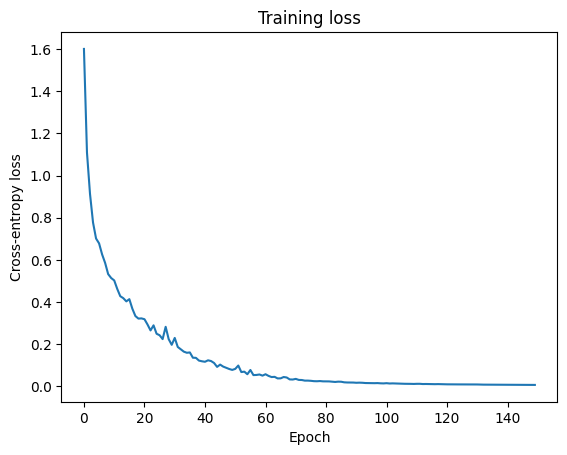

In [4]:
# Plotting the training loss
plt.plot(pivec)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Training loss')
plt.show()

In [5]:
# Print some values of pivec
print(pivec[119])
print(pivec[100])
print(pivec[80])
print(pivec[60])
print(pivec[40])

0.009478032483853838
0.014702132534719832
0.023272256101590588
0.05712432337914881
0.1162686839240193


In [8]:
# Save and load trained matrices with no regularization
for idx, w in enumerate(W):
    np.save(f'W_{idx}_{str(no_nodes[1])}x{str(no_nodes[2])}_{no_classes}classes.npy', w)

pretrained = 0
if pretrained == 1:
    W_load = [np.load(f'W_{idx}_{str(no_nodes[1])}x{str(no_nodes[2])}_{no_classes}classes.npy') for idx in range(len(W))]
    W = W_load.copy()



# Preprocess test data
test_data = np.loadtxt("FashionMNIST2_test_1000.csv", delimiter=',').astype(int)
test_data = test_data[test_data[:, 0] < no_classes]
np.random.shuffle(test_data)

X_test = (test_data[:, 1:].T / 255.0).astype(np.float32)
N_test = X_test.shape[1]
Y_test = np.zeros((10, N_test), dtype=np.float32)
test_labels = test_data[:, 0].astype(int)
Y_test[test_labels, np.arange(N_test)] = 1

# Test predictions
On = np.zeros((10, N_test))
test_correct = 0

pivec2 = 0
for j in range(N_test):
    a1 = X_test[:, j].reshape(-1, 1)
    a = [a1]
    n = []
    for i in range(len(W) - 1):
        n.append(W[i].T @ a[i] + b[i])
        a.append(sig2(n[i]))
    n.append(W[-1].T @ a[-1] + b[-1])
    a.append(sig3(n[-1]))

    if np.argmax(a[-1]) == np.argmax(Y_test[:, j]):
        test_correct += 1
    print(f"Predicted: {np.argmax(a[-1])}, Actual: {np.argmax(Y_test[:, j])} \n Accuracy: {test_correct}/{j+1}={test_correct/(j+1)*100:.2f}%")

    xent = -np.sum(Y_test[:, j] * np.log(a[-1].flatten() + 1e-8))
    pivec2 += xent/N_train

print(f"Test loss: {pivec2}")
print(f"Test accuracy: {test_correct/N_test*100:.2f}%")

# Count unique labels in test data
unique, counts = np.unique(test_data[:, 0], return_counts=True)
print(dict(zip(unique, counts)))


Predicted: 0, Actual: 0 
 Accuracy: 1/1=100.00%
Predicted: 1, Actual: 1 
 Accuracy: 2/2=100.00%
Predicted: 9, Actual: 9 
 Accuracy: 3/3=100.00%
Predicted: 0, Actual: 3 
 Accuracy: 3/4=75.00%
Predicted: 8, Actual: 8 
 Accuracy: 4/5=80.00%
Predicted: 6, Actual: 6 
 Accuracy: 5/6=83.33%
Predicted: 3, Actual: 0 
 Accuracy: 5/7=71.43%
Predicted: 1, Actual: 1 
 Accuracy: 6/8=75.00%
Predicted: 4, Actual: 4 
 Accuracy: 7/9=77.78%
Predicted: 4, Actual: 4 
 Accuracy: 8/10=80.00%
Predicted: 0, Actual: 0 
 Accuracy: 9/11=81.82%
Predicted: 1, Actual: 1 
 Accuracy: 10/12=83.33%
Predicted: 0, Actual: 0 
 Accuracy: 11/13=84.62%
Predicted: 8, Actual: 8 
 Accuracy: 12/14=85.71%
Predicted: 0, Actual: 0 
 Accuracy: 13/15=86.67%
Predicted: 7, Actual: 7 
 Accuracy: 14/16=87.50%
Predicted: 1, Actual: 1 
 Accuracy: 15/17=88.24%
Predicted: 5, Actual: 5 
 Accuracy: 16/18=88.89%
Predicted: 5, Actual: 5 
 Accuracy: 17/19=89.47%
Predicted: 0, Actual: 0 
 Accuracy: 18/20=90.00%
Predicted: 7, Actual: 7 
 Accuracy: 1

[8.1972749  7.93381473 7.13823646 6.92617453 6.13530361 6.00686671
 5.57382503 4.73451248 4.44586473 4.22718274 4.08246322 3.95948196
 3.85725254 3.75988695 3.66542878 3.56132677 3.49808801 3.41068763
 3.33744433 3.14309445 3.07381879 2.99984131 2.98385896 2.91494835
 2.83224497 2.6917008  2.65354893 2.52186089 2.48949959 2.44264479
 2.39173876 2.22923086 2.21017407 2.11340744 2.08356608 1.99718281
 1.91904404 1.87354063 1.85390745 1.79779871 1.67561362 1.59781145
 1.56861306 1.47075396 1.44224715 1.33190724 1.21498315 1.12117434
 1.0420529  0.8958724 ]


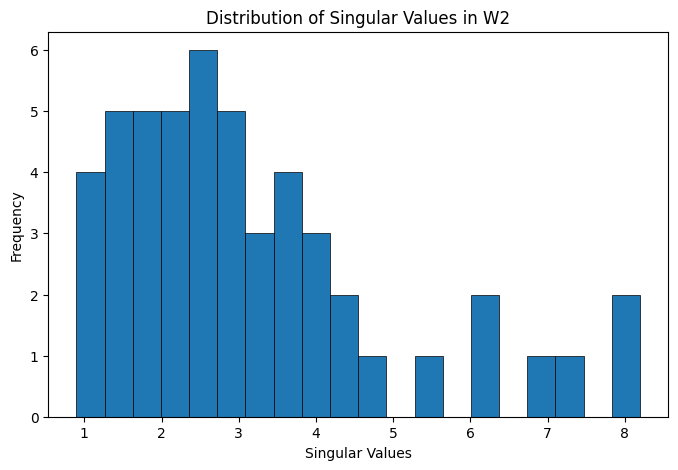

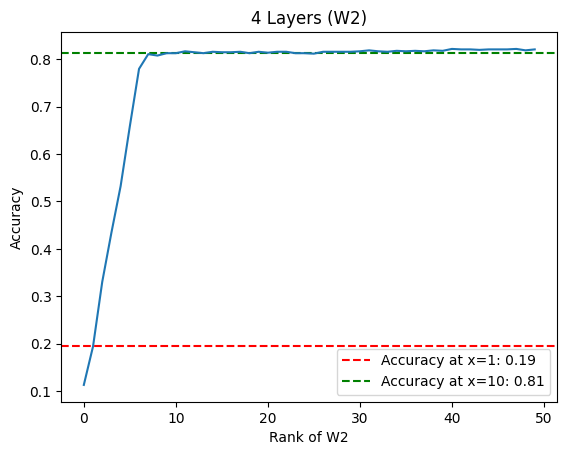

In [9]:
# Singular Value Decomposition (SVD) and low-rank approximation
k=1
U,S,VT = np.linalg.svd(W[k].copy())
plt.figure(figsize=(8, 5))
S_ordered = np.sort(S.copy())[::-1]
print(S)
plt.hist(S_ordered, bins=20, edgecolor='black', linewidth=0.5)
plt.xlabel("Singular Values")
plt.ylabel("Frequency")
plt.title(f"Distribution of Singular Values in W{k+1}")
plt.show()
range_s = range(len(S))
# if len(S) > 100:
#     range_s = range(0, len(S), 3)

Testing_Accuracy = []
for j in range_s:
    sum = np.zeros(W[k].shape)   
    for i in range_s:
        if S[i] > S[j]:
            u_i = U[:,i].reshape(-1,1)
            vt_i = VT[i,:].reshape(-1,1)
            # print(f"{S[i]} * \n{u_i} @ \n{vt_i.T}\n\n")
            matrix = S[i] * u_i @ vt_i.T
            # print("S[i] = ", S[i])
            # print("Matrix of size ", matrix.shape)
            sum += matrix

    W_lowrank = W.copy()
    W_lowrank[k] = sum.copy()
    test_correct =0

    # Re-evaulation
    for j in range(N_test):
        a1 = X_test[:, j].reshape(-1, 1)
        a = [a1]
        n = []
        for i in range(len(W) - 1):
            n.append(W_lowrank[i].T @ a[i] + b[i])
            a.append(sig2(n[i]))
        n.append(W_lowrank[-1].T @ a[-1] + b[-1])
        a.append(sig3(n[-1]))
        if np.argmax(a[-1]) == np.argmax(Y_test[:, j]):
            test_correct += 1
        
    Testing_Accuracy.append(test_correct/N_test)




y_value_at_x1 = Testing_Accuracy[1]
plt.axhline(y=y_value_at_x1, color='r', linestyle='--', label=f"Accuracy at x=1: {y_value_at_x1:.2f}")
y_value_at_x2 = Testing_Accuracy[no_classes]
plt.axhline(y=y_value_at_x2, color='g', linestyle='--', label=f"Accuracy at x={no_classes}: {y_value_at_x2:.2f}")
plt.plot(range_s, Testing_Accuracy)
plt.xlabel(f"Rank of W{k+1}")
plt.ylabel("Accuracy")
plt.title(f"{len(no_nodes)} Layers (W{k+1})")
plt.legend()

In [10]:
np.save(f'Testing_Accuracy_{str(no_nodes[k+1])}', Testing_Accuracy)

Rank 25



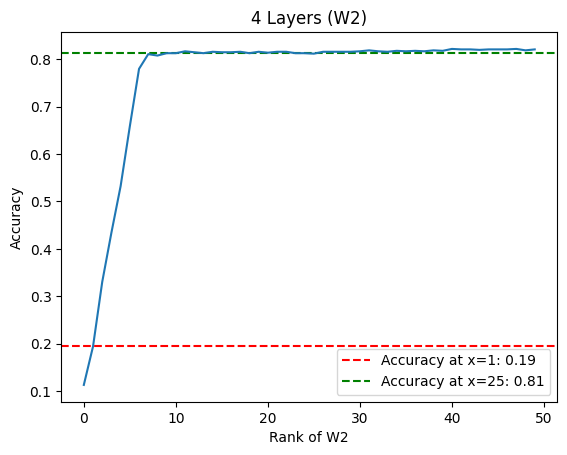

In [11]:
no_ranks = int(len(S)/2)
print(f'Rank {no_ranks}')
y_value_at_x1 = Testing_Accuracy[1]
plt.axhline(y=y_value_at_x1, color='r', linestyle='--', label=f"Accuracy at x=1: {y_value_at_x1:.2f}")
y_value_at_x2 = Testing_Accuracy[no_ranks-1]
plt.axhline(y=y_value_at_x2, color='g', linestyle='--', label=f"Accuracy at x={no_ranks}: {y_value_at_x2:.2f}")
plt.plot(range_s, Testing_Accuracy)
plt.xlabel(f"Rank of W{k+1}")
plt.ylabel("Accuracy")
plt.title(f"{len(no_nodes)} Layers (W{k+1})")
plt.legend()

print()

(50, 50)
min eigvec: 3.4575463296879e-09
max eigvec: 0.18891173861575353
mean eigvec: 0.020000000000000007
std eigvec: 0.026791841002780176
Upper Bound: 14.600869937494549
450


KS Statistic: 0.07777777777777778
P-value: 0.13145776467779705
Fail to reject the null (similar distributions)


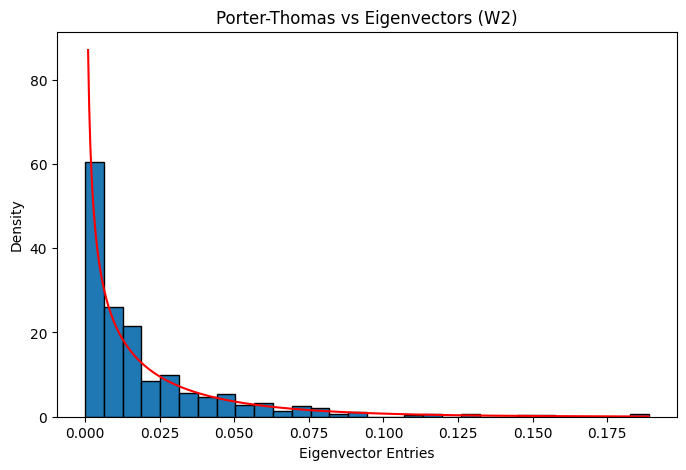

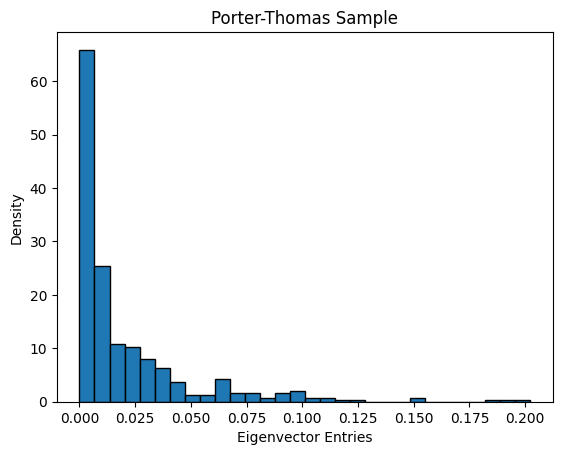

In [12]:
# Poerter-Thomas Distribution 
from scipy.stats import ks_2samp

k = 1
k_m = no_nodes[k]
k_n = no_nodes[k + 1]

wish = W[k].copy().T @ W[k].copy()
print(wish.shape)
eigvalues, eigvecs = np.linalg.eigh(wish)
eigvec_collection = (eigvecs[:, 1:10].copy()).flatten()
eigvec = ((eigvec_collection)**2)
# eigvec = ((eigvecs[:, 0].copy()/np.linalg.norm(eigvecs[:,0]))**2)
print(f"min eigvec: {np.min(eigvec)}")
print(f"max eigvec: {np.max(eigvec)}")
print(f"mean eigvec: {np.mean(eigvec)}")
print(f"std eigvec: {np.std(eigvec)}")

plt.figure(figsize=(8,5))

def pt_pdf(x):
    return (np.sqrt(k_n/(2*np.pi*x)))*np.exp((-k_n*x)/2)

z = np.linspace(0.001,np.max(eigvec), 500)
porter_thomas = pt_pdf(z)


# Now we will use Acceptance-Rejection Sampling to compare the two distributions
# We will sample from the Porter-Thomas distribution and compare it to the eigenvector distribution
length_eigvec = len(eigvec)
porter_thomas_sample = []
lambda_ = 1/np.mean(eigvec)

def exponen(x):
    return lambda_*np.exp(-lambda_*x)

upper_bound = np.max(pt_pdf(np.linspace(0.001,np.max(eigvec)))/exponen(np.linspace(0.001,np.max(eigvec))))

print("Upper Bound:", upper_bound)
print(length_eigvec)

while len(porter_thomas_sample) < length_eigvec:
    u = np.random.uniform(0, 1)
    y = np.random.exponential(scale=1/lambda_)
    # print(len(porter_thomas_sample))
    
    if u <= (pt_pdf(y)/(exponen(y)*upper_bound)):
        porter_thomas_sample.append(y)

stat, p_val = ks_2samp(porter_thomas_sample,eigvec)

print("\n")
print("KS Statistic:", stat)
print("P-value:", p_val)

if p_val > 0.05:
    print("Fail to reject the null (similar distributions)")
else:
    print("Reject the null (different distribution)")

# A comparison of the two distributions
plt.hist(eigvec, bins=30, edgecolor='black',density=True)
plt.plot(z, porter_thomas, 'r-')
plt.title(f"Porter-Thomas vs Eigenvectors (W{k + 1})")
plt.ylabel("Density")
plt.xlabel("Eigenvector Entries")
plt.show()

# Sample from the Porter-Thomas distribution
plt.hist(porter_thomas_sample, bins=30, edgecolor='black',density=True)
plt.title(f"Porter-Thomas Sample")
plt.ylabel("Density")
plt.xlabel("Eigenvector Entries")
plt.show()


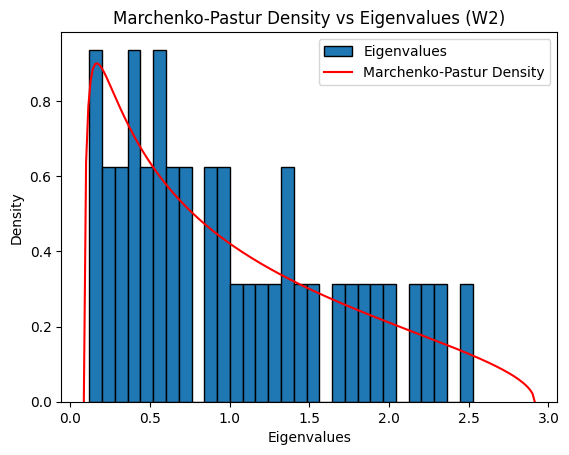

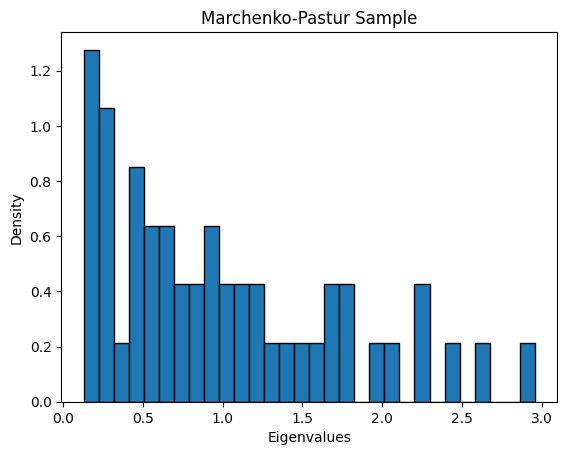

KS Statistic: 0.075
P-value: 0.9986554835663757
Fail to reject the null (similar distributions)


In [17]:
# Marchenko-Pastur Distribution
k_1 = 1
W_k_copy = W[k_1].copy()
W_k_norm = (W_k_copy - np.mean(W_k_copy))/(np.std(W_k_copy))

# This is the number of rows and columns in the matrix
k_1_m = no_nodes[k_1]
k_1_n = no_nodes[k_1 + 1]

S_matrix = (1/k_1_n)* W_k_norm.T @ W_k_norm

eigsvals, eigsvecs = np.linalg.eigh(S_matrix)
# print(eigsvals)
lambda_vals = np.linspace(min(eigsvals), max(eigsvals), 200)

aspectratio = k_1_n/k_1_m
lambdaplus = (1 + np.sqrt(aspectratio))**2
lambdaminus = (1 - np.sqrt(aspectratio))**2

def mp_pdf(x):
    return (1/(2*np.pi*aspectratio*x))*np.sqrt((lambdaplus - x)*(x - lambdaminus))

lambda_vals = np.linspace(lambdaminus, lambdaplus, 200)
marcenko_pastur = mp_pdf(lambda_vals)

plt.hist(eigsvals[:-no_classes], bins=30, edgecolor='black',density=True, label="Eigenvalues")
plt.plot(lambda_vals, marcenko_pastur, 'r-', label="Marchenko-Pastur Density")
plt.title(f"Marchenko-Pastur Density vs Eigenvalues (W{k_1 + 1})")
plt.ylabel("Density")
plt.xlabel("Eigenvalues")
plt.legend()
plt.show()

length_eigvals = len(eigsvals[:-no_classes])
G = np.random.normal(size=(k_1_m,k_1_n))
S = (1/k_1_m)*np.dot(G.T, G)
marcenko_pastur_sample = np.linalg.eigvals(S)
plt.hist(marcenko_pastur_sample, bins=30, edgecolor='black',density=True)
plt.title("Marchenko-Pastur Sample")
plt.ylabel("Density")
plt.xlabel("Eigenvalues")
plt.show()

stat, p_val = ks_2samp(marcenko_pastur_sample,eigsvals[:-no_classes])

print("KS Statistic:", stat)
print("P-value:", p_val)

if p_val > 0.05:
    print("Fail to reject the null (similar distributions)")
else:
    print("Reject the null (different distribution)")

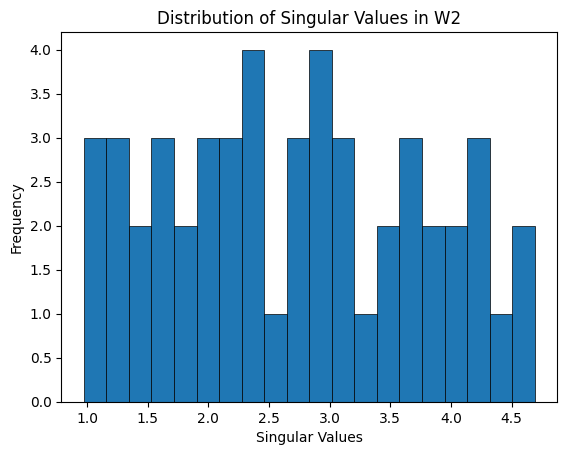

KS Statistic: 0.075
P-value: 0.9986554835663757
Fail to reject the null (similar distributions)


In [18]:
randmat = np.random.rand(W[1].shape[0], W[1].shape[1]) - 0.5
ner, eigen, ber = np.linalg.svd(randmat)

plt.hist(eigen, bins=20, edgecolor='black', linewidth=0.5)
plt.xlabel("Singular Values")
plt.ylabel("Frequency")
plt.title(f"Distribution of Singular Values in W{k+1}")
plt.show()

stat2, pval2 = ks_2samp(S, eigen)

print("KS Statistic:", stat)
print("P-value:", p_val)

if p_val > 0.05:
    print("Fail to reject the null (similar distributions)")
else:
    print("Reject the null (different distribution)")

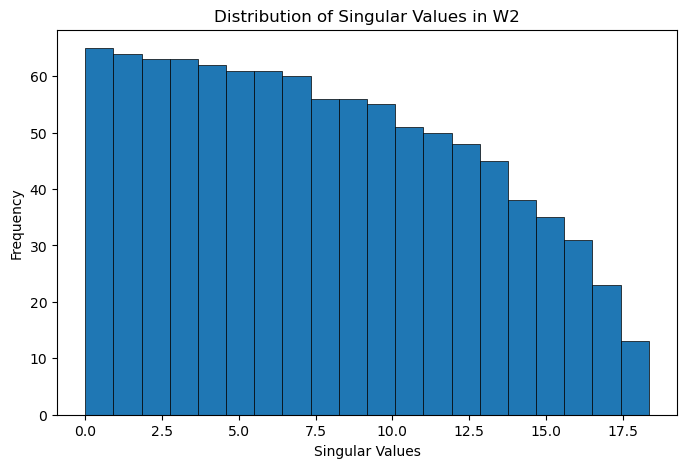